# Russian Morphology Analyzer Demo

This notebook mirrors the README workflow:
1. Analyze a single word
2. Analyze a sentence
3. Analyze a batch of lines from file
4. Run dataset evaluation

## Setup

If dependencies are missing, run one of these commands based on your current folder:

From workspace root (`CS_Language_Portfolio`):
`pip install -r projects/Russian_Morphology_Analyzer/requirements.txt`

From `projects/Russian_Morphology_Analyzer/code`:
`pip install -r ../requirements.txt`

In [8]:
from __future__ import annotations

import json
from pathlib import Path

# Robust imports for both notebook cwd options (project root or code/).
try:
    from analyzer import analyze_word, analyze_sentence, analyze_batch
    from evaluate import evaluate_dataset
    from utils import DATA_DIR, OUTPUT_DIR
except ImportError:
    from code.analyzer import analyze_word, analyze_sentence, analyze_batch
    from code.evaluate import evaluate_dataset
    from code.utils import DATA_DIR, OUTPUT_DIR

def show(obj):
    print(json.dumps(obj, ensure_ascii=False, indent=2))

print(f'DATA_DIR: {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

DATA_DIR: C:\Users\Nikolai\OneDrive\Desktop\Portfolio\CS_Language_Portfolio\projects\Russian_Morphology_Analyzer\data
OUTPUT_DIR: C:\Users\Nikolai\OneDrive\Desktop\Portfolio\CS_Language_Portfolio\projects\Russian_Morphology_Analyzer\data\outputs


## 1) Single-Word Analysis

In [9]:
word = "книгами"  # Try: читал, лучшего, люди
result = analyze_word(word)
show(result)

{
  "token": "книгами",
  "lemma": "книга",
  "part_of_speech": "noun",
  "case": "instrumental",
  "gender": "feminine",
  "number": "plural",
  "tense": null,
  "person": null,
  "aspect": null,
  "animacy": null,
  "analysis_source": "dictionary"
}


## 2) Sentence Analysis

In [10]:
text = "Я читаю интересные книги"
sentence_results = analyze_sentence(text)
show(sentence_results)

[
  {
    "token": "Я",
    "lemma": "я",
    "part_of_speech": "pronoun",
    "case": null,
    "gender": null,
    "number": "singular",
    "tense": null,
    "person": "first",
    "aspect": null,
    "animacy": null,
    "analysis_source": "dictionary"
  },
  {
    "token": "читаю",
    "lemma": "читать",
    "part_of_speech": "verb",
    "case": null,
    "gender": null,
    "number": "singular",
    "tense": "present",
    "person": "first",
    "aspect": "imperfective",
    "animacy": null,
    "analysis_source": "dictionary"
  },
  {
    "token": "интересные",
    "lemma": "интересный",
    "part_of_speech": "adjective",
    "case": "accusative",
    "gender": null,
    "number": "plural",
    "tense": null,
    "person": null,
    "aspect": null,
    "animacy": null,
    "analysis_source": "dictionary"
  },
  {
    "token": "книги",
    "lemma": "книга",
    "part_of_speech": "noun",
    "case": "accusative",
    "gender": "feminine",
    "number": "plural",
    "tense": null

## 3) Batch Analysis From File

In [11]:
sample_file = DATA_DIR / "sample_sentences_ru.txt"
lines = [line.strip() for line in sample_file.read_text(encoding="utf-8").splitlines() if line.strip()]

print(f"Loaded {len(lines)} lines from {sample_file.name}")
# Set to None to analyze the full file, or set an integer for a quick subset.
batch_limit = None
run_count = len(lines) if batch_limit is None else min(batch_limit, len(lines))
print(f"Running batch analysis on {run_count} line(s)...")

batch_results = analyze_batch(lines[:run_count])
show(batch_results)

Loaded 40 lines from sample_sentences_ru.txt
Running batch analysis on 40 line(s)...
[
  [
    {
      "token": "Книгами",
      "lemma": "книга",
      "part_of_speech": "noun",
      "case": "instrumental",
      "gender": "feminine",
      "number": "plural",
      "tense": null,
      "person": null,
      "aspect": null,
      "animacy": null,
      "analysis_source": "dictionary"
    },
    {
      "token": "интересуются",
      "lemma": "интересоваться",
      "part_of_speech": "verb",
      "case": null,
      "gender": null,
      "number": "plural",
      "tense": "present",
      "person": "third",
      "aspect": "imperfective",
      "animacy": null,
      "mood": "indicative",
      "voice": null,
      "transitivity": "intransitive",
      "involvement": null,
      "raw_tag": "VERB,impf,intr plur,3per,pres,indc",
      "analysis_source": "pymorphy3",
      "confidence": 1.0,
      "is_known_word": true,
      "candidates": [
        {
          "lemma": "интересоваться"

## 4) Evaluation on Labeled Dataset

This computes metrics from `data/evaluation_dataset.csv` and writes
`data/outputs/evaluation_results.json`.

In [12]:
metrics = evaluate_dataset()
show(metrics)

results_path = OUTPUT_DIR / "evaluation_results.json"
print(f"Saved metrics to: {results_path}")

{
  "examples": 120,
  "lemma_accuracy": 0.992,
  "part_of_speech_accuracy": 1.0,
  "case_accuracy": 0.989,
  "gender_accuracy": 0.989,
  "number_accuracy": 1.0,
  "tense_accuracy": 1.0,
  "aspect_accuracy": 1.0,
  "person_accuracy": 1.0
}
Saved metrics to: C:\Users\Nikolai\OneDrive\Desktop\Portfolio\CS_Language_Portfolio\projects\Russian_Morphology_Analyzer\data\outputs\evaluation_results.json


## 5) Standard Morphology Visualizations

These plots summarize analyzer quality and behavior on the evaluation dataset:
1. Per-feature accuracy
2. POS confusion matrix
3. Analysis-source coverage

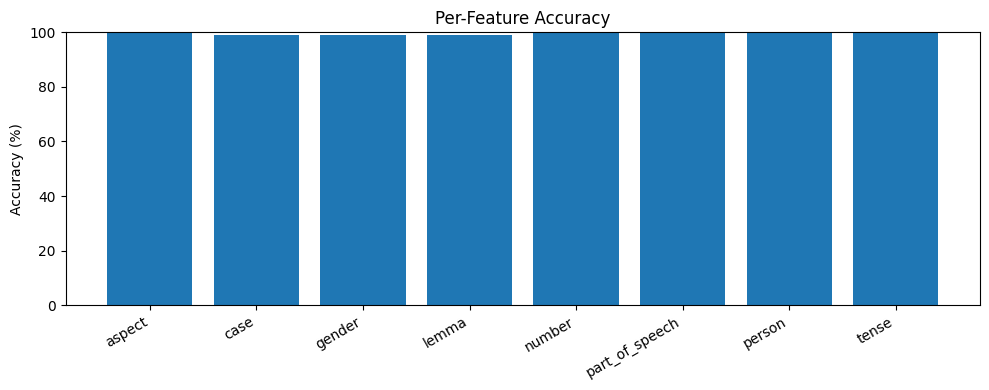

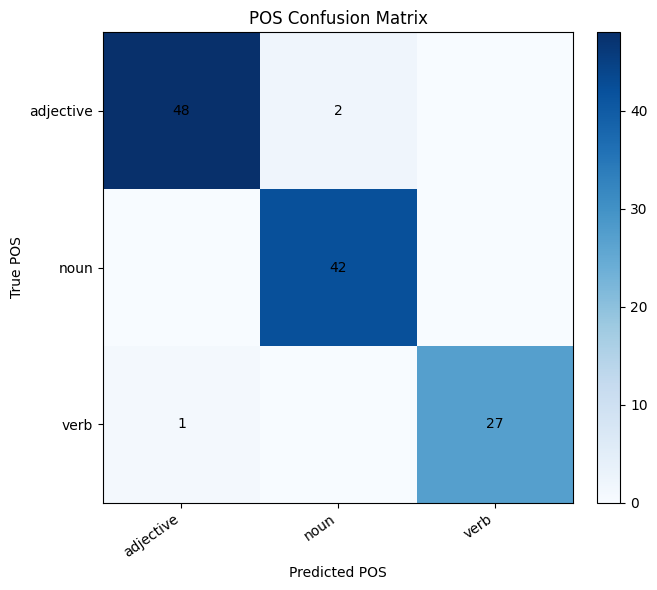

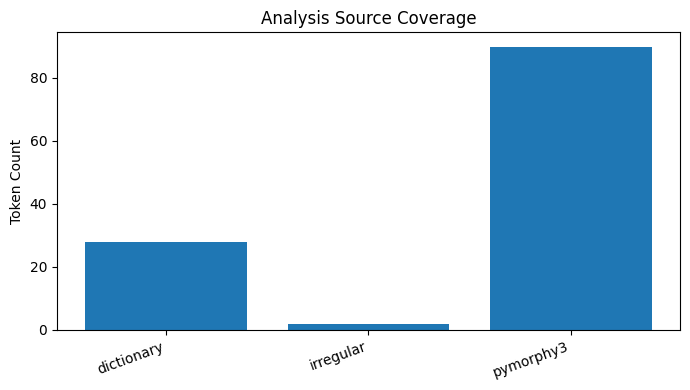

Examples visualized: 120


In [13]:
from collections import Counter
import csv

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise RuntimeError(
        "matplotlib is required for visualization. Install with: pip install matplotlib"
    ) from exc

# Reuse existing metrics if present; otherwise compute now.
if "metrics" not in globals():
    metrics = evaluate_dataset()

# 1) Per-feature accuracy bar chart
feature_scores = {
    key.replace("_accuracy", ""): value
    for key, value in metrics.items()
    if key.endswith("_accuracy")
}

if feature_scores:
    ordered = sorted(feature_scores.items(), key=lambda kv: kv[0])
    labels = [k for k, _ in ordered]
    values = [v * 100 for _, v in ordered]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values)
    plt.ylim(0, 100)
    plt.ylabel("Accuracy (%)")
    plt.title("Per-Feature Accuracy")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Build predictions over evaluation dataset once for subsequent plots.
eval_rows = []
dataset_path = DATA_DIR / "evaluation_dataset.csv"
with dataset_path.open("r", encoding="utf-8") as handle:
    for row in csv.DictReader(handle):
        token = (row.get("token") or "").strip()
        if not token:
            continue
        pred = analyze_word(token)
        eval_rows.append((row, pred))

# 2) POS confusion matrix
pos_labels = sorted({
    (row.get("part_of_speech") or "").strip()
    for row, _ in eval_rows
    if (row.get("part_of_speech") or "").strip()
} | {
    (pred.get("part_of_speech") or "unknown").strip()
    for _, pred in eval_rows
})

index = {label: i for i, label in enumerate(pos_labels)}
matrix = [[0 for _ in pos_labels] for _ in pos_labels]

for row, pred in eval_rows:
    true_pos = (row.get("part_of_speech") or "").strip()
    pred_pos = (pred.get("part_of_speech") or "unknown").strip()
    if true_pos in index and pred_pos in index:
        matrix[index[true_pos]][index[pred_pos]] += 1

if pos_labels:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title("POS Confusion Matrix")
    ax.set_xlabel("Predicted POS")
    ax.set_ylabel("True POS")
    ax.set_xticks(range(len(pos_labels)))
    ax.set_yticks(range(len(pos_labels)))
    ax.set_xticklabels(pos_labels, rotation=35, ha="right")
    ax.set_yticklabels(pos_labels)

    for i in range(len(pos_labels)):
        for j in range(len(pos_labels)):
            value = matrix[i][j]
            if value:
                ax.text(j, i, str(value), ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# 3) Analysis-source coverage
source_counts = Counter(
    (pred.get("analysis_source") or "unknown")
    for _, pred in eval_rows
 )

if source_counts:
    labels = list(source_counts.keys())
    values = [source_counts[label] for label in labels]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values)
    plt.ylabel("Token Count")
    plt.title("Analysis Source Coverage")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

print(f"Examples visualized: {len(eval_rows)}")

## 5) Robustness Checks

Quick checks for reproducibility and expected analyzer behavior.

In [14]:
import platform
import sys

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")

try:
    import pymorphy3
    print(f"pymorphy3: {pymorphy3.__version__}")
except Exception:
    print("pymorphy3: not installed")

checks = [
    {"token": "книгами", "lemma": "книга", "part_of_speech": "noun"},
    {"token": "читаю", "lemma": "читать", "part_of_speech": "verb"},
    {"token": "люди", "lemma": "человек", "part_of_speech": "noun"},
    {"token": "сделают", "lemma": "сделать", "part_of_speech": "verb", "tense": "future"},
    {"token": "будем", "lemma": "быть", "part_of_speech": "verb", "tense": "future"},
]

passed = 0
for case in checks:
    token = case["token"]
    result = analyze_word(token)
    ok = True
    mismatches = []
    for field, expected in case.items():
        if field == "token":
            continue
        actual = result.get(field)
        if actual != expected:
            ok = False
            mismatches.append(f"{field}: expected={expected}, got={actual}")

    status = "PASS" if ok else "FAIL"
    print(f"{status} - {token}")
    if mismatches:
        for msg in mismatches:
            print(f"  {msg}")
    else:
        passed += 1

print(f"Checks passed: {passed}/{len(checks)}")
if passed < len(checks):
    print("Some checks failed. Review dictionary/rules or environment consistency.")

Python: 3.13.3
Platform: Windows-11-10.0.26200-SP0
pymorphy3: 2.0.4
PASS - книгами
PASS - читаю
PASS - люди
PASS - сделают
PASS - будем
Checks passed: 5/5


## Optional Interactive Controls

In [15]:
def run_analysis(text: str, mode: str = "sentence"):
    if mode == "word":
        return analyze_word(text)
    return analyze_sentence(text)

try:
    import ipywidgets as widgets
    from IPython.display import display

    mode = widgets.ToggleButtons(
        options=[("Word", "word"), ("Sentence", "sentence")],
        description="Mode:",
    )
    text_input = widgets.Text(
        value="Я читаю интересные книги",
        description="Input:",
        layout=widgets.Layout(width="80%"),
    )
    button = widgets.Button(description="Analyze")
    output = widgets.Output()

    def on_click(_):
        with output:
            output.clear_output()
            result = run_analysis(text_input.value, mode.value)
            show(result)

    button.on_click(on_click)
    display(mode, text_input, button, output)
except ImportError:
    print("ipywidgets is not installed. Use the function below instead:")
    print("run_analysis('книгами', mode='word')")
    print("run_analysis('Я читаю интересные книги', mode='sentence')")

ToggleButtons(description='Mode:', options=(('Word', 'word'), ('Sentence', 'sentence')), value='word')

Text(value='Я читаю интересные книги', description='Input:', layout=Layout(width='80%'))

Button(description='Analyze', style=ButtonStyle())

Output()